# **Hello Soft Clustering (GMM)**

Recall from HW1 we did K-means clustering. Fitting a GMM on a set of points can be considered as another method to do clustering but now with soft assignments. Consider the same set of points we used in HW1.

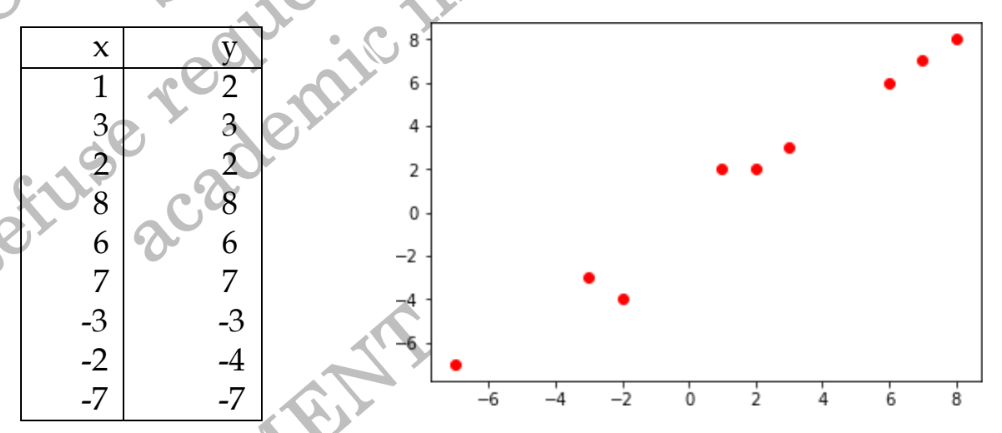

In class, we showed that we could fit a GMM on 1-dimensional data by using Expectation Maximization (EM). The algorithm for doing EM on N-dimensional GMM is very similar. The exact algorithm is as follows:

**Initialization:** Initialize the mixture weights, $φ = {m_j}$, where $j$ is the mixture number, means of each Gaussian $μ_j$ (now a vector of $N$ dimensions), and covariance matrices of each Gaussian, $Σ_j$

**Expectation:** Find the soft assignments for each data point $w_{n,j}$ where $n$ corresponds to the sample index.

$$w_{n,j} = \frac{p(\mathbf{x}_n; \vec{\mu}_j, \Sigma_j)m_j}{\sum_{j} p(\mathbf{x}_n; \vec{\mu}_j, \Sigma_j)m_j}$$

$w_{n,j}$ means the probability that data point $n$ comes from Gaussian number.

**Note:** For the generalized Gaussian is then given by

$$p(\mathbf{x}; \boldsymbol{\mu}, \Sigma) = \frac{1}{\sqrt{(2\pi)^k |\Sigma|}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)$$

where $k$ is the number of variables and $|Σ|$ is the determinant of $Σ$. The above equation is used for full covariance matrices. For our example, we will use diagonal covariance matrices, which can be acquired by setting the off-diagonal values to zero. In other words, $Σ(i,j) = 0$, for $i ≠ j$.

**Maximization:** Update the model parameters, $φ, μ_j, Σ_j$

$$m_j = \frac{1}{N} \sum_{n=1}^{N} w_{n,j}$$

$$\vec{\mu}_j = \frac{\sum_{n=1}^{N} w_{n,j} \mathbf{x}_n}{\sum_{n=1}^{N} w_{n,j}}$$

$$\Sigma_j = \frac{\sum_{n=1}^{N} w_{n,j} (\mathbf{x}_n - \vec{\mu}_j)(\mathbf{x}_n - \vec{\mu}_j)^T}{\sum_{n=1}^{N} w_{n,j}}$$

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [20]:
# ==========================================
# 1. INITIALIZATION 
# ==========================================
def initialize(X, n_components=3, start_means=None):
    """Initializes pi (weights), mu (means), and cov (covariances)."""
    N, d = X.shape
    K = n_components
    
    if start_means is not None:
        mu = np.array(start_means, dtype=float)
        K = len(mu) # Overrides n_components if means dictate otherwise
    else:
        # Random selection of data points as initial cluster centers
        random_indices = np.random.choice(N, K, replace=False)
        mu = X[random_indices].astype(float)
        
    pi = np.ones(K) / K  # Equal identical mixing weights
    cov = np.array([np.eye(d) for _ in range(K)]) # Identity matrices
    
    return pi, mu, cov

In [21]:
# ==========================================
# 2. EXPECTATION (E-Step)
# ==========================================
def expectation(X, pi, mu, cov):
    """Calculates the responsibility matrix (w_nj) for points to Gaussians."""
    N, d = X.shape
    K = len(pi)
    gamma = np.zeros((N, K))
    
    for k in range(K):
        try:
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=cov[k])
        except np.linalg.LinAlgError:
            # Adds standard regularizer if points perfectly collapse to singular vectors
            cov[k] += np.eye(d) * 1e-6 
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=cov[k])
            
    # Normalize across configurations to sum 1
    likelihood = np.sum(gamma, axis=1)
    likelihood[likelihood == 0] = 1e-10 # Prevent zero-division edge cases
    w_nj = (gamma.T / likelihood).T
    
    return w_nj

In [22]:
# ==========================================
# 3. MAXIMIZATION (M-Step)
# ==========================================
def maximization(X, w_nj):
    """Updates the model pi, mu, and cov parameters based on expected responsibilities."""
    N, d = X.shape
    K = w_nj.shape[1]
    
    m_j = np.sum(w_nj, axis=0) # Effective point cluster weighting
    
    mu = np.zeros((K, d))
    cov = np.zeros((K, d, d))
    
    for k in range(K):
        if m_j[k] > 1e-10:
            # Update Center/Mean 
            mu[k] = (1 / m_j[k]) * np.sum(w_nj[:, k].reshape(-1, 1) * X, axis=0)
            
            # Update Variance spread around new center
            diff = X - mu[k]
            cov[k] = (1 / m_j[k]) * np.dot((w_nj[:, k].reshape(-1, 1) * diff).T, diff)
            
        cov[k] += np.eye(d) * 1e-6 # Light regularization added purely for numerical stability
        
    # Update Mixture global probabilities
    pi = m_j / N
    
    return pi, mu, cov, m_j

In [23]:
# ==========================================
# MAIN LOOP CO-ORDINATOR 
# ==========================================
def run_em_gmm(X, n_components=3, start_means=None, iterations=5):
    """Coordinates initialize, E-step, M-step and plots results per iteration"""
    d = X.shape[1]
    
    # 1. Init Step
    pi, mu, cov = initialize(X, n_components=n_components, start_means=start_means)
    K = len(pi)
    
    # 🌟 NEW: Initialize list to track log-likelihood changes
    log_likelihood_history = []
        
    # Plot Grid Setup
    if d == 2:
        x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
        y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        pos = np.dstack((xx, yy))
        cmap = plt.get_cmap('tab10') 
        
    for iteration in range(iterations):
        print(f"\n{'='*15} Iteration {iteration + 1} {'='*15}\n")

        # 2. Expectation Step 
        w_nj = expectation(X, pi, mu, cov)
        
        # 🌟 NEW: Calculate the Log-Likelihood right here
        current_likelihood_sum = np.zeros(X.shape[0])
        for k in range(K):
            # Same probability math, but checking for singular matrix exceptions 
            try:
                current_likelihood_sum += pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=cov[k])
            except np.linalg.LinAlgError:
                # Add tiny stability check
                safe_cov = cov[k] + np.eye(d) * 1e-6
                current_likelihood_sum += pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=safe_cov)
                
        # Prevent math errors if a probability rounds to absolute 0
        current_likelihood_sum[current_likelihood_sum == 0] = 1e-10 
        
        # Convert to sum of Logs and append 
        current_ll = np.sum(np.log(current_likelihood_sum))
        log_likelihood_history.append(current_ll)
        # ========================================================

        print("w_{n,j} (Responsibilities Matrix):")
        print(np.round(w_nj, 4))
        
        # 3. Plot Checkpoint Visual
        if d == 2:
            plt.figure(figsize=(8, 6))
            plt.scatter(X[:, 0], X[:, 1], c='black', label='Data Points', zorder=5)
            for k in range(K):
                try:
                    rv = multivariate_normal(mu[k], cov[k])
                    plt.contour(xx, yy, pi[k] * rv.pdf(pos), colors=[cmap(k)], alpha=0.5)
                    plt.plot([], [], color=cmap(k), label=f'Gaussian {k+1}') 
                except (ValueError, np.linalg.LinAlgError):
                    pass 
            plt.title(f'EM Iteration {iteration + 1} - Gaussian Mixtures')
            plt.xlabel('Feature X')
            plt.ylabel('Feature Y')
            plt.legend()
            plt.grid(True)
            plt.show()

        # 4. Maximization Step 
        pi, mu, cov, m_j = maximization(X, w_nj)

        print("\nm_j (Effective weight factor per mixture):")
        print(np.round(m_j, 4))
        
        print("\nμ_j (Updated Means):")
        print(np.round(mu, 4))
        
        print("\nΣ_j (Updated Covariance Matrices):")
        for k in range(K):
            print(f" Mixture {k+1}:\n", np.round(cov[k], 4))
            
    # 🌟 NEW: Make sure to return the history array out of the function block!
    return log_likelihood_history


In [24]:
# Test Set
X_data = np.array([
    [1, 2], [3, 3], [2, 2], [8, 8], [6, 6], 
    [7, 7], [-3, -3], [-2, -4], [-7, -7]
], dtype=float)

### **1. Using 3 mixtures, initialize your Gaussian with means (3,3), (2,2), and (-3,-3), and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three iterations of EM. Write down $w_{n,j}, m_j, μ_j, Σ_j$ and plot the likelihood distributions (3 Gaussians) of each feature for each EM iteration. (You may do the calculations by hand or write code to do so)** *(5 points)*


=============== Iteration 1 ===============

w_{n,j} (Responsibilities Matrix):
[[1.192e-01 8.808e-01 0.000e+00]
 [7.311e-01 2.689e-01 0.000e+00]
 [2.689e-01 7.311e-01 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [9.991e-01 9.000e-04 0.000e+00]
 [9.999e-01 1.000e-04 0.000e+00]
 [0.000e+00 0.000e+00 1.000e+00]
 [0.000e+00 0.000e+00 1.000e+00]
 [0.000e+00 0.000e+00 1.000e+00]]


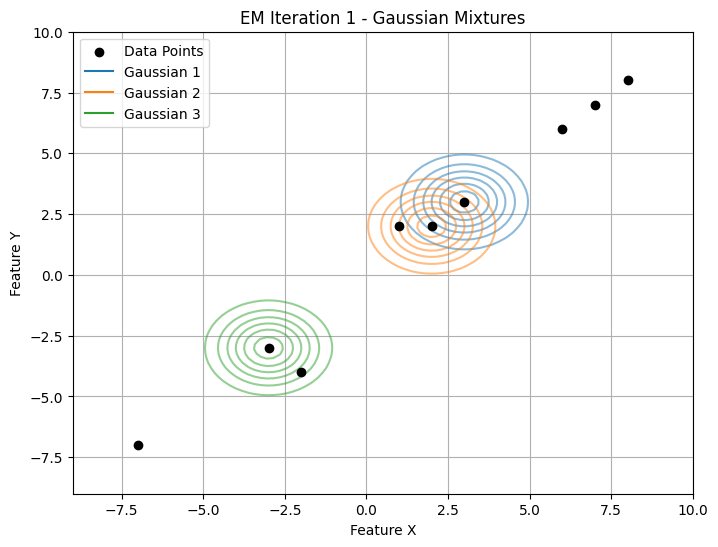


m_j (Effective weight factor per mixture):
[4.1182 1.8818 3.    ]

μ_j (Updated Means):
[[ 5.7899  5.8189]
 [ 1.6772  2.1452]
 [-4.     -4.6667]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[4.5362 4.3975]
 [4.3975 4.287 ]]
 Mixture 2:
 [[0.5165 0.1995]
 [0.1995 0.1315]]
 Mixture 3:
 [[4.6667 3.3333]
 [3.3333 2.8889]]

=============== Iteration 2 ===============

w_{n,j} (Responsibilities Matrix):
[[0.000e+00 1.000e+00 0.000e+00]
 [8.528e-01 1.472e-01 0.000e+00]
 [2.417e-01 7.583e-01 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [5.000e-04 0.000e+00 9.995e-01]
 [0.000e+00 0.000e+00 1.000e+00]
 [0.000e+00 0.000e+00 1.000e+00]]


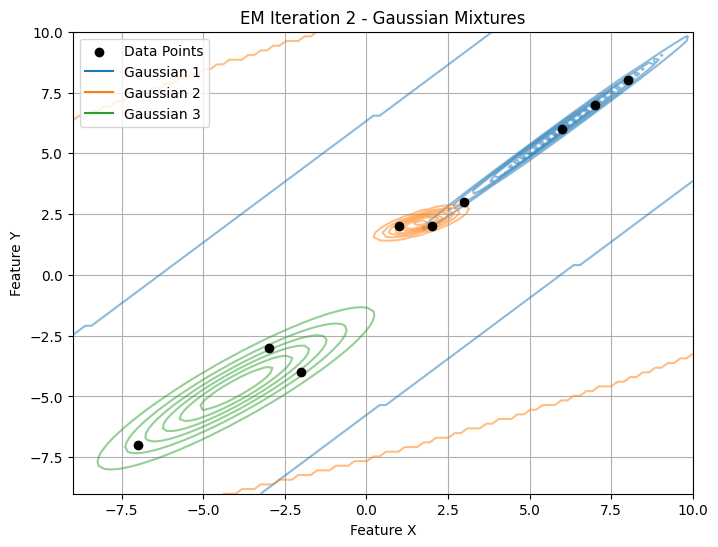


m_j (Effective weight factor per mixture):
[4.0951 1.9054 2.9995]

μ_j (Updated Means):
[[ 5.8705  5.8705]
 [ 1.5524  2.0772]
 [-4.0001 -4.6669]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[4.0337 4.0337]
 [4.0337 4.0337]]
 Mixture 2:
 [[0.4017 0.1118]
 [0.1118 0.0713]]
 Mixture 3:
 [[4.6676 3.334 ]
 [3.334  2.8893]]

=============== Iteration 3 ===============

w_{n,j} (Responsibilities Matrix):
[[0.000e+00 1.000e+00 0.000e+00]
 [9.999e-01 1.000e-04 0.000e+00]
 [9.695e-01 3.050e-02 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00]
 [1.041e-01 0.000e+00 8.959e-01]
 [0.000e+00 0.000e+00 1.000e+00]
 [0.000e+00 0.000e+00 1.000e+00]]


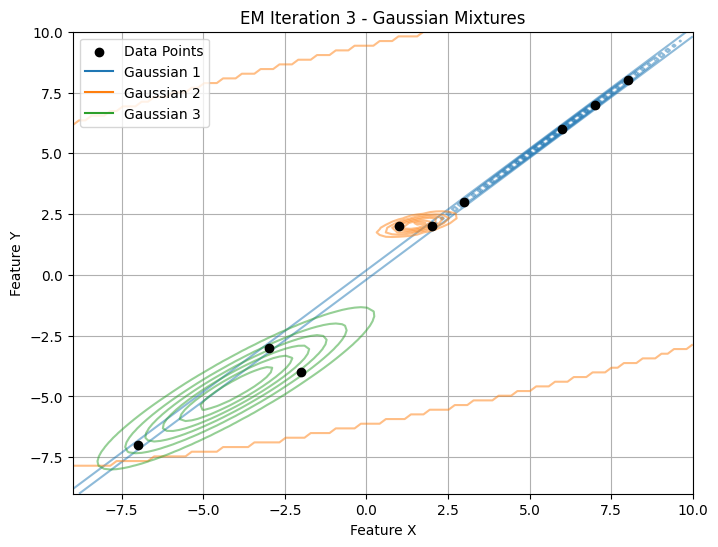


m_j (Effective weight factor per mixture):
[5.0735 1.0306 2.8959]

μ_j (Updated Means):
[[ 5.051   5.051 ]
 [ 1.0298  2.0001]
 [-4.0359 -4.7266]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[6.578 6.578]
 [6.578 6.578]]
 Mixture 2:
 [[0.029  0.0001]
 [0.0001 0.0001]]
 Mixture 3:
 [[4.7972 3.3911]
 [3.3911 2.8893]]

=============== Iteration 4 ===============

w_{n,j} (Responsibilities Matrix):
[[0.     1.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [0.9426 0.     0.0574]
 [0.     0.     1.    ]
 [0.0298 0.     0.9702]]


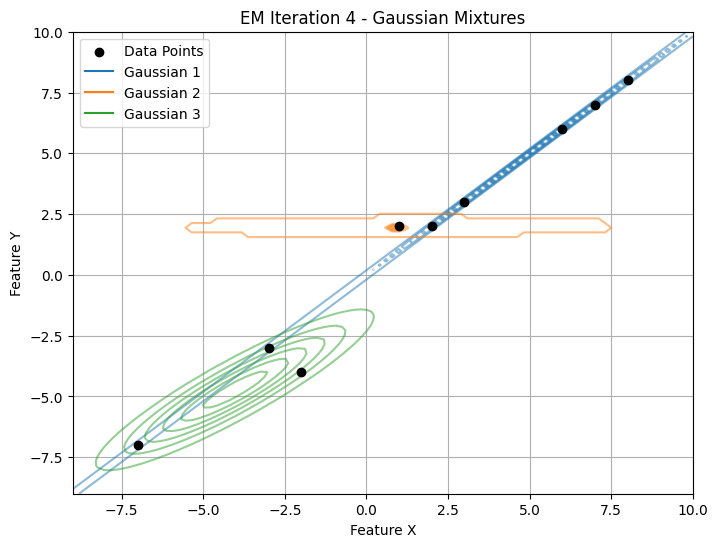


m_j (Effective weight factor per mixture):
[5.9725 1.     2.0275]

μ_j (Updated Means):
[[ 3.8449  3.8449]
 [ 1.      2.    ]
 [-4.4207 -5.4072]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[14.0069 14.0069]
 [14.0069 14.0069]]
 Mixture 2:
 [[0. 0.]
 [0. 0.]]
 Mixture 3:
 [[6.1305 3.7426]
 [3.7426 2.3546]]

=============== Iteration 5 ===============

w_{n,j} (Responsibilities Matrix):
[[0.     1.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [0.     0.     1.    ]
 [0.9041 0.     0.0959]]


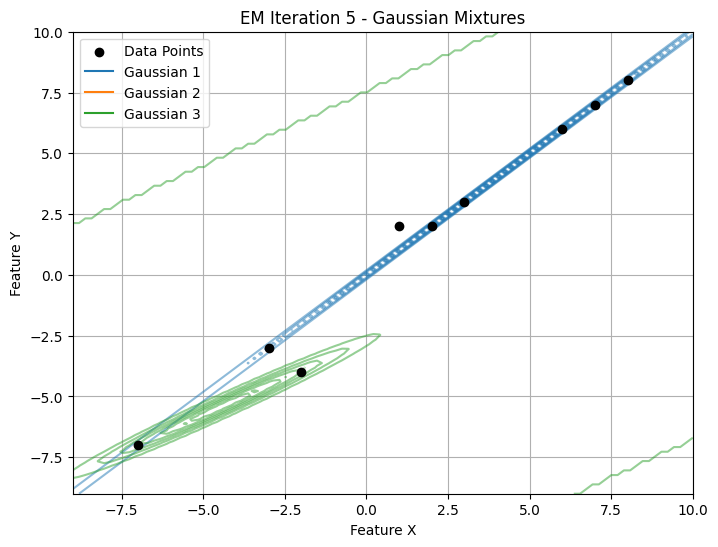


m_j (Effective weight factor per mixture):
[6.9041 1.     1.0959]

μ_j (Updated Means):
[[ 2.4147  2.4147]
 [ 1.      2.    ]
 [-2.4376 -4.2625]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[25.3537 25.3537]
 [25.3537 25.3537]]
 Mixture 2:
 [[0. 0.]
 [0. 0.]]
 Mixture 3:
 [[1.9964 1.1979]
 [1.1979 0.7187]]


In [25]:
custom_centers = [[3, 3], [2, 2], [-3, -3]]

# Calling Sequence
history_output = run_em_gmm(X=X_data, start_means=custom_centers, iterations=5)


### **2. Plot the log likelihood of the model given the data after each EM step. Does it goes up every iteration just as we learned in class?** *(3 points)*

In [26]:
def plot_log_likelihood(log_likelihood_history):
    """
    Plots the log-likelihood trace after each Expectation-Maximization step.
    
    Parameters:
    - log_likelihood_history: A list or array of the log-likelihood values recorded during each EM iteration.
    """
    iterations = len(log_likelihood_history)
    
    plt.figure(figsize=(8, 5))
    
    # Plotting the trace
    plt.plot(range(1, iterations + 1), log_likelihood_history, 
             marker='o', markersize=8, linestyle='-', color='purple', linewidth=2)
    
    # Graph Formatting
    plt.title('Log-Likelihood of GMM given Data across Iterations', fontsize=14)
    plt.xlabel('EM Iteration Number', fontsize=12)
    plt.ylabel('Log-Likelihood', fontsize=12)
    plt.xticks(range(1, iterations + 1)) # Integer ticks depending on the run length
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()


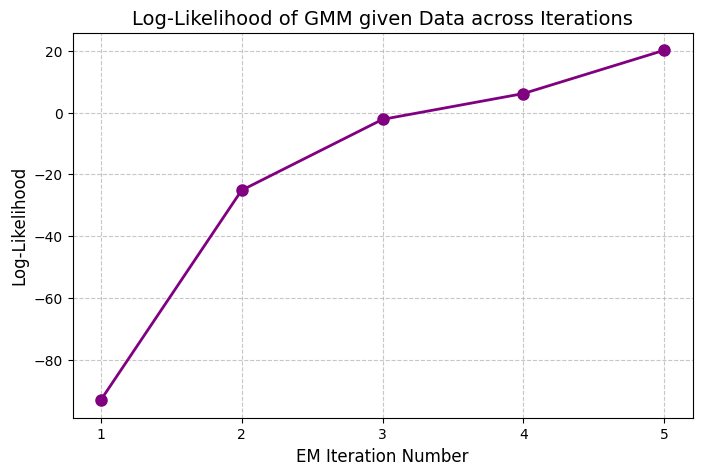

In [27]:
plot_log_likelihood(history_output)

### **3. Using 2 mixtures, initialize your Gaussian with means (3,3), and (3,-3), and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three iterations of EM. Write down $w_{n,j}, m_j, μ_j, Σ_j$ and plot the likelihood distributions (2 Gaussians) of each feature for each EM iteration.** *(5 points)*


=============== Iteration 1 ===============

w_{n,j} (Responsibilities Matrix):
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


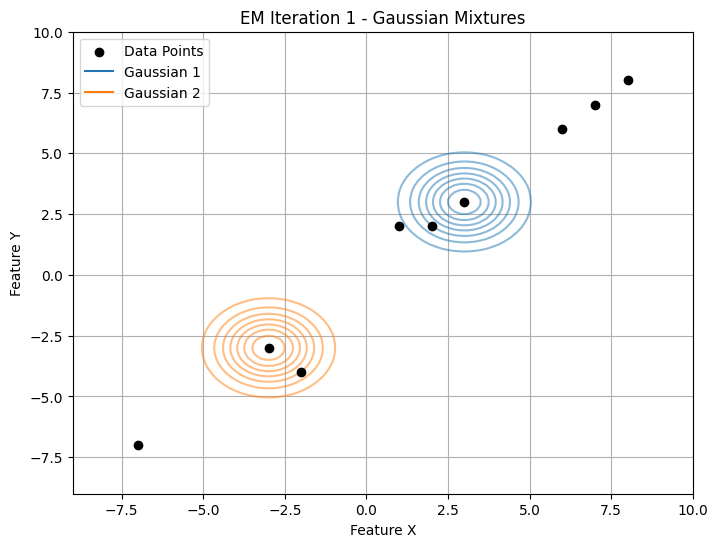


m_j (Effective weight factor per mixture):
[6. 3.]

μ_j (Updated Means):
[[ 4.5     4.6667]
 [-4.     -4.6667]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[6.9167 6.3333]
 [6.3333 5.8889]]
 Mixture 2:
 [[4.6667 3.3333]
 [3.3333 2.8889]]

=============== Iteration 2 ===============

w_{n,j} (Responsibilities Matrix):
[[1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [9.999e-01 1.000e-04]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [5.200e-03 9.948e-01]
 [0.000e+00 1.000e+00]
 [0.000e+00 1.000e+00]]


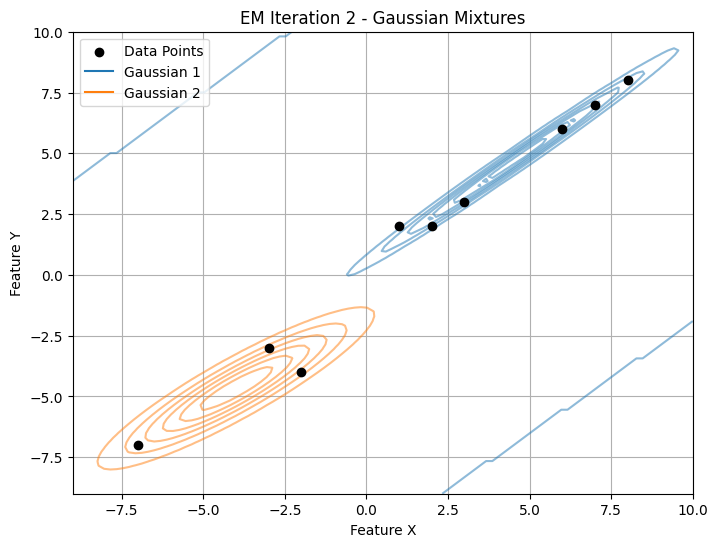


m_j (Effective weight factor per mixture):
[6.0051 2.9949]

μ_j (Updated Means):
[[ 4.4936  4.6601]
 [-4.0015 -4.6693]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[6.9589 6.3772]
 [6.3772 5.9342]]
 Mixture 2:
 [[4.6739 3.3373]
 [3.3373 2.8903]]

=============== Iteration 3 ===============

w_{n,j} (Responsibilities Matrix):
[[1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [9.999e-01 1.000e-04]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [5.700e-03 9.943e-01]
 [0.000e+00 1.000e+00]
 [0.000e+00 1.000e+00]]


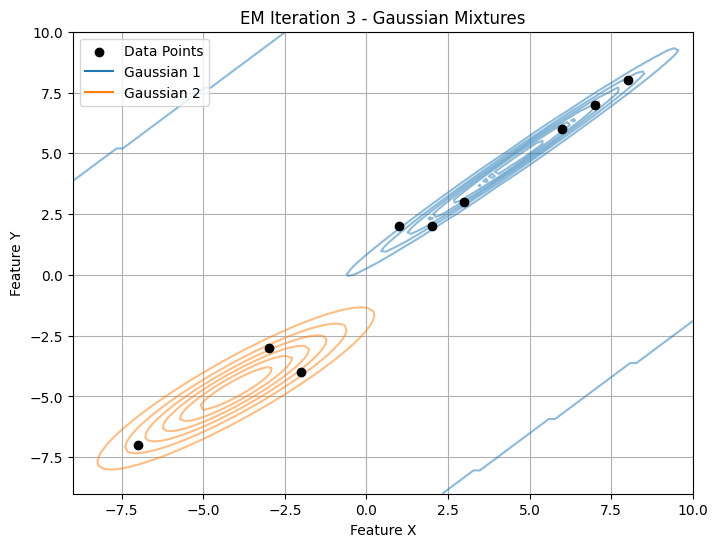


m_j (Effective weight factor per mixture):
[6.0056 2.9944]

μ_j (Updated Means):
[[ 4.4929  4.6594]
 [-4.0017 -4.6697]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[6.9637 6.3821]
 [6.3821 5.9393]]
 Mixture 2:
 [[4.6745 3.3376]
 [3.3376 2.8903]]

=============== Iteration 4 ===============

w_{n,j} (Responsibilities Matrix):
[[1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [9.999e-01 1.000e-04]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [5.800e-03 9.942e-01]
 [0.000e+00 1.000e+00]
 [0.000e+00 1.000e+00]]


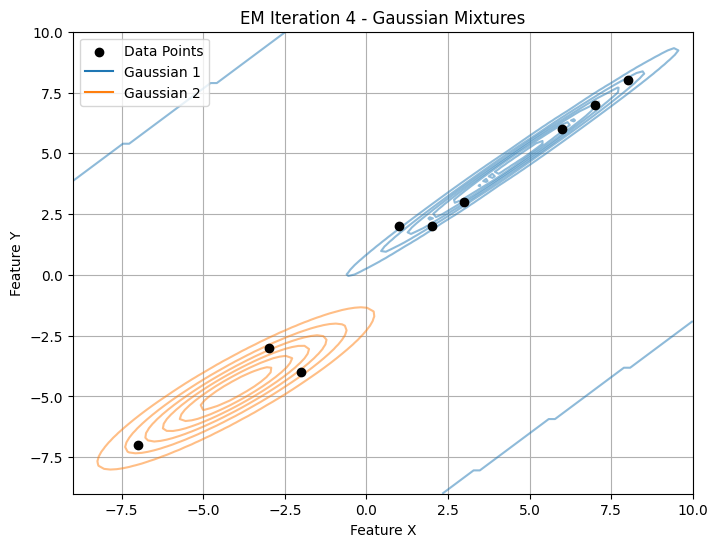


m_j (Effective weight factor per mixture):
[6.0057 2.9943]

μ_j (Updated Means):
[[ 4.4928  4.6593]
 [-4.0018 -4.6697]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[6.9642 6.3826]
 [6.3826 5.9399]]
 Mixture 2:
 [[4.6746 3.3376]
 [3.3376 2.8903]]

=============== Iteration 5 ===============

w_{n,j} (Responsibilities Matrix):
[[1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [9.999e-01 1.000e-04]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [5.800e-03 9.942e-01]
 [0.000e+00 1.000e+00]
 [0.000e+00 1.000e+00]]


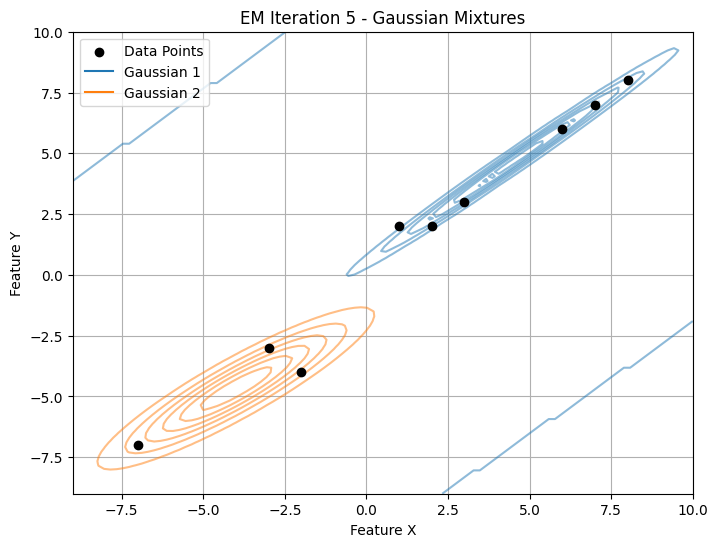


m_j (Effective weight factor per mixture):
[6.0057 2.9943]

μ_j (Updated Means):
[[ 4.4928  4.6593]
 [-4.0018 -4.6697]]

Σ_j (Updated Covariance Matrices):
 Mixture 1:
 [[6.9643 6.3827]
 [6.3827 5.9399]]
 Mixture 2:
 [[4.6746 3.3376]
 [3.3376 2.8903]]


In [28]:
custom_centers = [[3, 3], [-3, -3]]

history_output = run_em_gmm(X=X_data, start_means=custom_centers, iterations=5)

### **4. Plot the log likelihood of the model given the data after each EM step. Compare the log likelihood between using two mixtures and three mixtures. Which one has the better likelihood?** *(3 points)*

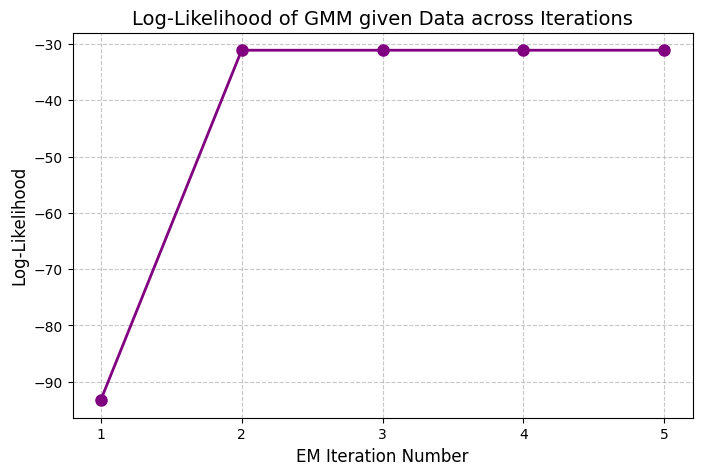

In [29]:
plot_log_likelihood(history_output)